Imports


In [155]:
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

EDA


In [156]:
df = pd.read_csv('Group20_RawData.csv')
df.head()

,id,title,link,content,gold_label
0,0,نیٹ فلکس ڈاؤن، سوشل میڈیا پر شکایتوں کا طوفان ...,https://www.express.pk/story/2733439/netflix-d...,معروف امریکی اسٹریمنگ پلیٹ فارم نیٹ فلکس باکسن...,entertainment
1,1,پاکستانی ویب سیریز ’فروٹ چاٹ‘ کی شوٹنگ کا آغا...,https://www.express.pk/story/2733408/the-shoot...,عالمی ایوارڈ یافتہ پاکستان شوبز کے نوجوان ہدای...,entertainment
2,2,ریاض میں رنگارنگ فیشن شو، جینیفر لوپیز سمیت دی...,https://www.express.pk/story/2733380/a-colorfu...,سعودی عرب کےدارالحکومتریاض میں منعقد ہونے والے...,entertainment
3,3,دیشا پٹانی کے والد کے ساتھ لاکھوں روپے کا فراڈ...,https://www.express.pk/story/2733374/disha-pat...,بالی ووڈ کی خوبرو اداکارہ دیشا پٹانی کے والد،...,entertainment
4,4,ڈان 3 میں ولن کون ہوگا؟ نام سامنے آگیا,https://www.express.pk/story/2733372/who-will-...,بالی ووڈ کی مشہور فلم ’ڈان‘ فرنچائز کی تیسری ف...,entertainment


In [157]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 2332 rows and 5 columns.


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          2332 non-null   int64 
 1   title       2332 non-null   object
 2   link        2332 non-null   object
 3   content     2268 non-null   object
 4   gold_label  2332 non-null   object
dtypes: int64(1), object(4)
memory usage: 91.2+ KB


In [159]:
df.describe()

,id
count,2332.000000
mean,1165.500000
std,673.334736
min,0.000000
25%,582.750000
50%,1165.500000
75%,1748.250000
max,2331.000000


In [160]:
print(df['gold_label'].value_counts())

gold_label
sports                468
entertainment         467
science-technology    467
world                 466
business              464
Name: count, dtype: int64


In [161]:
print(df.isnull().sum())

id             0
title          0
link           0
content       64
gold_label     0
dtype: int64


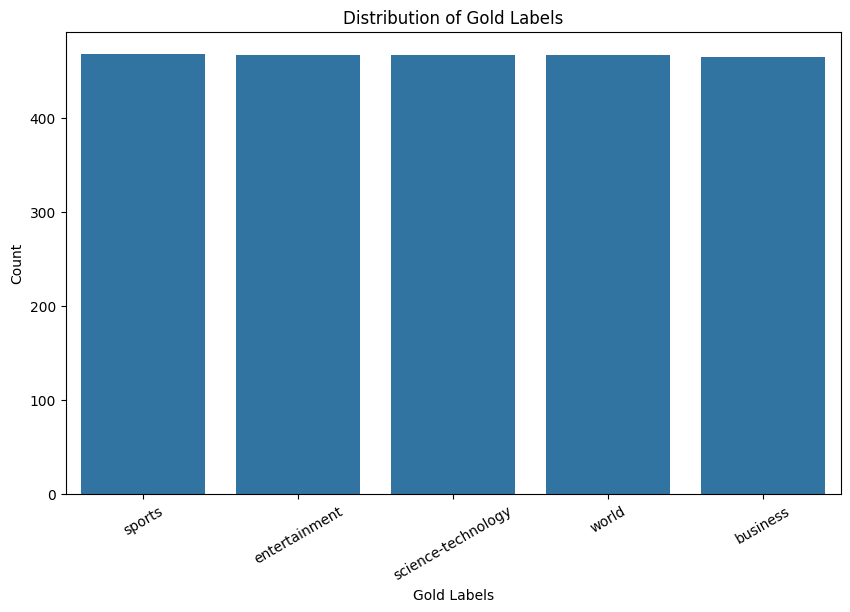

In [162]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gold_label', data=df,
              order=df['gold_label'].value_counts().index)
plt.title('Distribution of Gold Labels')
plt.xlabel('Gold Labels')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [163]:
df['gold_label'].unique()

array(['entertainment', 'business', 'sports', 'science-technology',
       'world'], dtype=object)

In [164]:
df['gold_label'] = df['gold_label'].str.strip()

In [165]:
df['title_length'] = df['title'].apply(len)
df['title_length'].describe()

count    2332.000000
mean       62.458834
std        13.666071
min        20.000000
25%        53.000000
50%        62.000000
75%        72.000000
max       123.000000
Name: title_length, dtype: float64

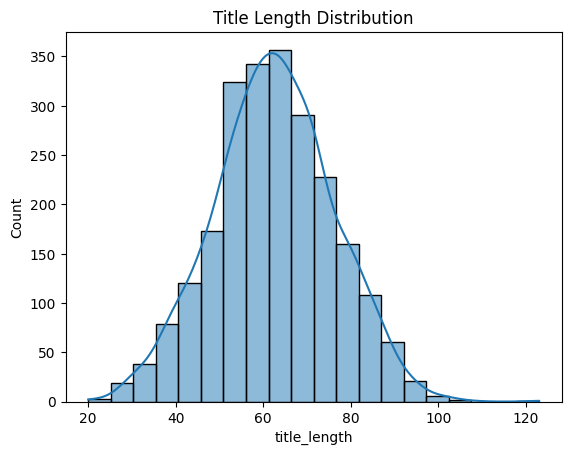

In [166]:
sns.histplot(df['title_length'], bins=20, kde=True)
plt.title('Title Length Distribution')
plt.show()

In [167]:
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=20)
bow_matrix = vectorizer.fit_transform(df['title'].fillna(''))
print(vectorizer.get_feature_names_out())

['ئی' 'اور' 'بھارتی' 'دیا' 'سی' 'سے' 'میں' 'نے' 'ٹرمپ' 'پاکستان' 'پر' 'پی'
 'کا' 'کر' 'کرنے' 'کو' 'کی' 'کیلئے' 'کے' 'ہے']


In [168]:
df['content'] = df['content'].fillna('')
df['content_length'] = df['content'].apply(len)
df['content_length'].describe()

count     2332.000000
mean      1052.078045
std        698.857259
min          0.000000
25%        652.750000
50%        915.500000
75%       1264.000000
max      10332.000000
Name: content_length, dtype: float64

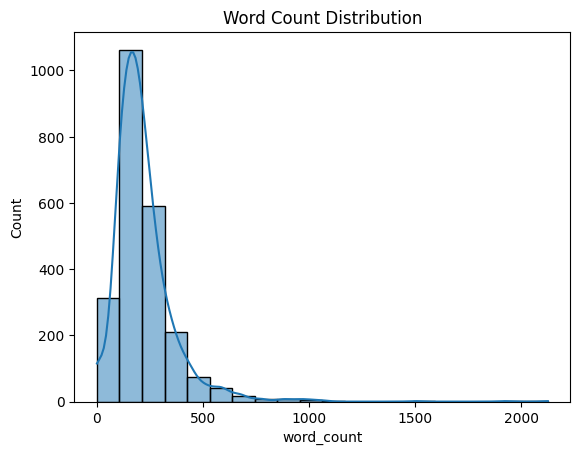

In [169]:
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=20, kde=True)
plt.title('Word Count Distribution')
plt.show()

In [170]:
df[df['content_length'] < 50]

,id,title,link,content,gold_label,title_length,content_length,word_count
171,171,قیمتوں میں بڑی کمی کے بعد سونا آج پھر مہنگا ہوگیا,https://www.express.pk/story/2732955/gold-pric...,,business,49,0,0
178,178,اسٹیٹ بینک نے فنکا مائیکروفنانس بینک کے شیئرز ...,https://www.express.pk/story/2732806/state-ban...,,business,69,0,0
183,183,سونے کی عالمی اور مقامی مارکیٹوں میں قیمت میں ...,https://www.express.pk/story/2732765/gold-pric...,,business,60,0,0
192,192,سونے کی عالمی اور مقامی مارکیٹوں میں قیمت کم ہ...,https://www.express.pk/story/2732572/gold-pric...,,business,51,0,0
195,195,اسٹاک ایکسچینج میں زبردست تیزی؛ انڈیکس 94 ہزار...,https://www.express.pk/story/2732517/stock-exc...,,business,72,0,0
...,...,...,...,...,...,...,...,...
559,559,26 قومی کرکٹرز ایبٹ آباد میں شیڈول ٹریننگ کیمپ...,https://www.express.pk/story/1305371/26qwmy-kr...,,science-technology,54,0,0
575,575,اسرائیل غزہ میں انسانی حقوق سے متعلق سنگین خدش...,https://www.express.pk/story/2733111/eu-foreig...,,world,94,0,0
615,615,مقبوضہ کشمیر میں بھارتی فوج پر حملہ؛ ایک افسر ...,https://www.express.pk/story/2732543/attack-on...,,world,68,0,0
637,637,جونا گڑھ پر بھارت کے غاصبانہ قبضے کو 77 سال مکمل,https://www.express.pk/story/2732266/junagadh-...,,world,48,0,0


DATA CLEANING


In [171]:
df.drop(columns=['link'], inplace=True)

In [172]:
df = df[df['title'].notna() | df['content'].notna()]

In [173]:
def clean_text(text):
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['title'] = df['title'].apply(clean_text)
df['content'] = df['content'].apply(clean_text)

Tokenization and Bag of Words


In [174]:
nlp = spacy.blank('ur')


def tokenize_text(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    return [token.text for token in doc]


df['title_tokens'] = df['title'].apply(tokenize_text)
df['content_tokens'] = df['content'].apply(tokenize_text)
df[['title', 'title_tokens', 'content', 'content_tokens']].head()

,title,title_tokens,content,content_tokens
0,نیٹ فلکس ڈاؤن سوشل میڈیا پر شکایتوں کا طوفان اگیا,"[نیٹ, فلکس, ڈاؤن, سوشل, میڈیا, پر, شکایتوں, کا...",معروف امریکی اسٹریمنگ پلیٹ فارم نیٹ فلکس باکسن...,"[معروف, امریکی, اسٹریمنگ, پلیٹ, فارم, نیٹ, فلک..."
1,پاکستانی ویب سیریز فروٹ چاٹ کی شوٹنگ کا اغاز ک...,"[پاکستانی, ویب, سیریز, فروٹ, چاٹ, کی, شوٹنگ, ک...",عالمی ایوارڈ یافتہ پاکستان شوبز کے نوجوان ہدای...,"[عالمی, ایوارڈ, یافتہ, پاکستان, شوبز, کے, نوجو..."
2,ریاض میں رنگارنگ فیشن شو جینیفر لوپیز سمیت دیگ...,"[ریاض, میں, رنگارنگ, فیشن, شو, جینیفر, لوپیز, ...",سعودی عرب کےدارالحکومتریاض میں منعقد ہونے والے...,"[سعودی, عرب, کےدارالحکومتریاض, میں, منعقد, ہون..."
3,دیشا پٹانی کے والد کے ساتھ لاکھوں روپے کا فراڈ...,"[دیشا, پٹانی, کے, والد, کے, ساتھ, لاکھوں, روپے...",بالی ووڈ کی خوبرو اداکارہ دیشا پٹانی کے والد ر...,"[بالی, ووڈ, کی, خوبرو, اداکارہ, دیشا, پٹانی, ک..."
4,ڈان میں ولن کون ہوگا نام سامنے اگیا,"[ڈان, میں, ولن, کون, ہوگا, نام, سامنے, اگیا]",بالی ووڈ کی مشہور فلم ڈان فرنچائز کی تیسری فلم...,"[بالی, ووڈ, کی, مشہور, فلم, ڈان, فرنچائز, کی, ..."


In [175]:
class BagOfWords:
    def __init__(self):
        self.vocab = {}

    def fit(self, documents):
        unique_words = set(word for doc in documents for word in doc)
        self.vocab = {word: idx for idx, word in enumerate(unique_words)}

    def transform(self, documents):
        rows = []
        for doc in documents:
            word_counts = Counter(doc)
            row = [word_counts.get(word, 0) for word in self.vocab]
            rows.append(row)
        return np.array(rows)


bow = BagOfWords()
bow.fit(df['title_tokens'] + df['content_tokens'])
X = bow.transform(df['title_tokens'] + df['content_tokens'])

Train Test Split and Lable Encoding


In [176]:
le = LabelEncoder()
y = le.fit_transform(df['gold_label'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69)
print("Training Data")
print(X_train.shape)
print(y_train.shape)
print("Testing Data")
print(X_test.shape)
print(y_test.shape)

Training Data
(1865, 21173)
(1865,)
Testing Data
(467, 21173)
(467,)


Neural Network


In [178]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [ ]:
input_size = X_train.shape[1]
num_classes = len(le.classes_)
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 50
train_losses = []
train_accuracies = []
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_train_tensor).sum().item() / \
        y_train_tensor.size(0)
    train_losses.append(loss.item())
    train_accuracies.append(accuracy)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item()          :.4f}, Accuracy: {accuracy * 100:.2f}%")

Epoch [1/50], Loss: 1.6289, Accuracy: 20.21%
Epoch [2/50], Loss: 1.4554, Accuracy: 45.25%
Epoch [3/50], Loss: 1.3597, Accuracy: 64.50%
Epoch [4/50], Loss: 1.2708, Accuracy: 78.45%
Epoch [5/50], Loss: 1.1883, Accuracy: 86.65%
Epoch [6/50], Loss: 1.1094, Accuracy: 90.56%
Epoch [7/50], Loss: 1.0248, Accuracy: 93.30%
Epoch [8/50], Loss: 0.9455, Accuracy: 94.85%
Epoch [9/50], Loss: 0.8691, Accuracy: 95.71%
Epoch [10/50], Loss: 0.8074, Accuracy: 96.62%
Epoch [11/50], Loss: 0.7330, Accuracy: 97.10%
Epoch [12/50], Loss: 0.6773, Accuracy: 96.84%
Epoch [13/50], Loss: 0.5994, Accuracy: 97.64%
Epoch [14/50], Loss: 0.5481, Accuracy: 98.18%
Epoch [15/50], Loss: 0.4887, Accuracy: 97.91%
Epoch [16/50], Loss: 0.4353, Accuracy: 98.23%
Epoch [17/50], Loss: 0.3865, Accuracy: 98.71%
Epoch [18/50], Loss: 0.3576, Accuracy: 98.55%
Epoch [19/50], Loss: 0.3127, Accuracy: 98.61%
Epoch [20/50], Loss: 0.2764, Accuracy: 98.93%
Epoch [21/50], Loss: 0.2402, Accuracy: 98.82%
Epoch [22/50], Loss: 0.2105, Accuracy: 99.0

Final Test Accuracy: 96.15%
Precision: 0.9627
Recall: 0.9623
F1 Score: 0.9621

Classification Report:
                    precision    recall  f1-score   support

          business       0.99      0.94      0.97       106
     entertainment       0.99      0.99      0.99        84
science-technology       0.92      0.99      0.95        95
            sports       1.00      0.97      0.98        90
             world       0.91      0.92      0.92        92

          accuracy                           0.96       467
         macro avg       0.96      0.96      0.96       467
      weighted avg       0.96      0.96      0.96       467



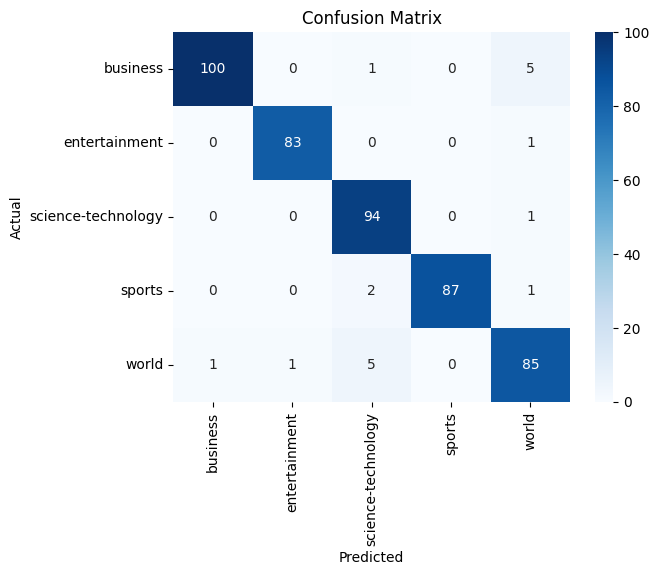

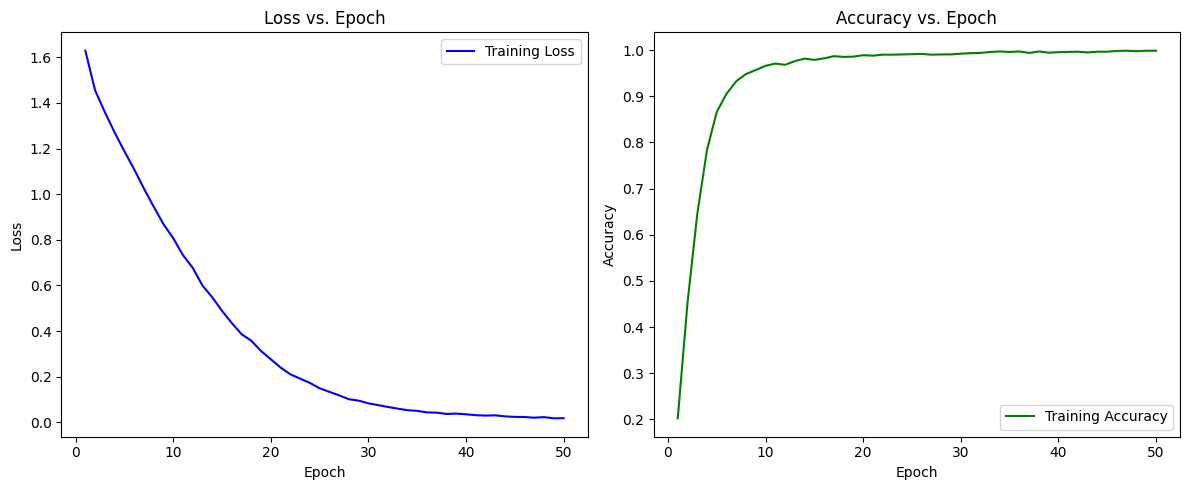

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_classes = torch.argmax(y_pred, axis=1)
final_accuracy = (y_pred_classes == y_test_tensor).sum(
).item() / y_test_tensor.size(0)
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

precision = precision_score(y_test_tensor, y_pred_classes, average='macro')
recall = recall_score(y_test_tensor, y_pred_classes, average='macro')
f1 = f1_score(y_test_tensor, y_pred_classes, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_tensor,
      y_pred_classes, target_names=le.classes_))
conf_matrix = confusion_matrix(y_test_tensor, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Training Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch")
plt.legend()
plt.tight_layout()
plt.show()